#SARIMA

SARIMA (Seasonal ARIMA) is an extension of ARIMA that models seasonality.

#🔢 SARIMA(p, d, q)(P, D, Q, s)
(p, d, q): ARIMA terms

(P, D, Q, s): Seasonal AR, differencing, MA, and seasonal period (e.g., s = 12 for monthly seasonality)

#🧮 Model Components:

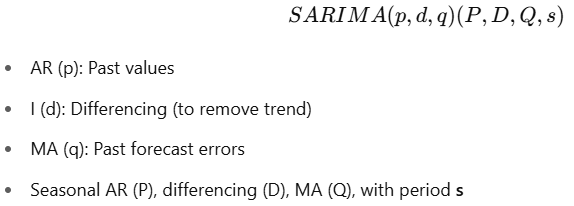

#⚙️ Install Required Libraries

In [7]:
pip install pandas numpy matplotlib statsmodels


#🔹 Step 1: Simulate Seasonal Data

/tmp/ipython-input-8-4119756.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.index = pd.date_range(start='2010-01', periods=periods, freq='M')


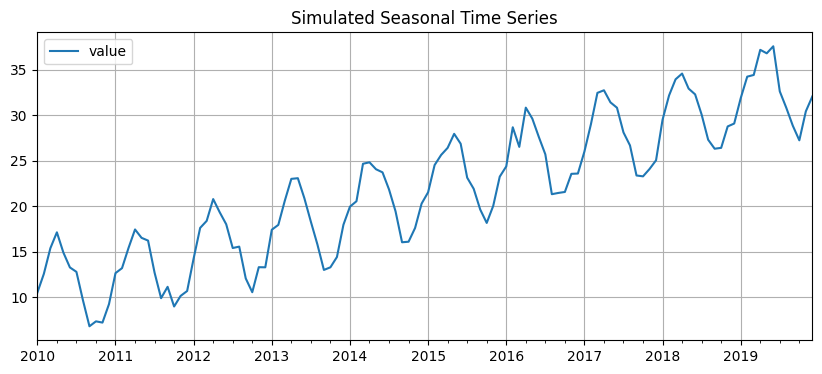

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate seasonal data with trend
np.random.seed(42)
periods = 120
time = np.arange(periods)
seasonal = 10 + np.sin(2 * np.pi * time / 12) * 5
trend = 0.2 * time
noise = np.random.normal(0, 1, periods)
data = trend + seasonal + noise

df = pd.DataFrame({'value': data})
df.index = pd.date_range(start='2010-01', periods=periods, freq='M')
df.plot(title="Simulated Seasonal Time Series", figsize=(10, 4))
plt.grid()
plt.show()


#🔹 Step 2: Fit SARIMA Model
Use SARIMA(p,d,q)(P,D,Q,s) → try (1,1,1)(1,1,1,12) for monthly data

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model
model = SARIMAX(df['value'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit()

# Summary
print(model_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -133.625
Date:                            Fri, 18 Jul 2025   AIC                            277.250
Time:                                    11:12:36   BIC                            289.913
Sample:                                01-31-2010   HQIC                           282.363
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0607      0.126     -0.482      0.630      -0.307       0.186
ma.L1         -1.0000     79.936   

#🔹 Step 3: Forecast & Plot

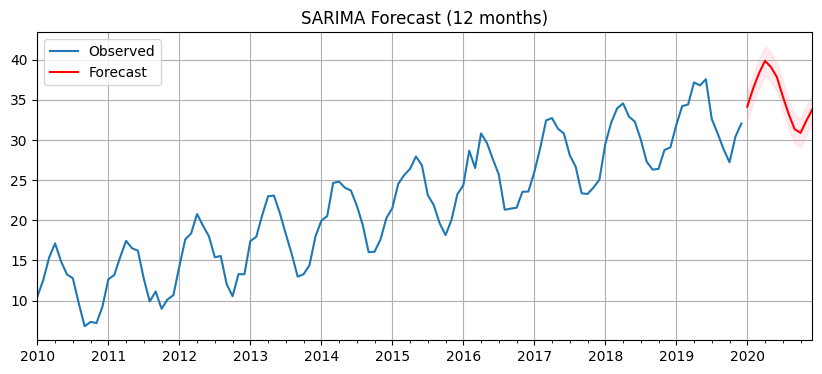

In [10]:
# Forecast next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_ci = forecast.conf_int()

# Plot forecast
ax = df['value'].plot(label='Observed', figsize=(10, 4))
forecast.predicted_mean.plot(ax=ax, label='Forecast', color='r')
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1], color='pink', alpha=0.3)

plt.title("SARIMA Forecast (12 months)")
plt.legend()
plt.grid()
plt.show()



#✅ When to Use SARIMA?

| Scenario                                               | Model    |
| ------------------------------------------------------ | -------- |
| No trend, no seasonality                               | ARMA     |
| Trend only                                             | ARIMA    |
| Trend + Seasonality (e.g., yearly or monthly patterns) | ✅ SARIMA |
